# PINN for the 1D Heat Equation

**PDE:** ∂u/∂t = α ∂²u/∂x²,  x∈[0,1], t∈[0,1]  
**IC:** u(x,0) = sin(πx)  
**BC:** u(0,t) = u(1,t) = 0  
**Exact:** u(x,t) = e^(−π²αt) sin(πx)

Same class of parabolic PDE solved via FDM in the course; here replaced by a mesh-free PINN.  
Motivated by Nayak et al., *Physics of Fluids* 37, 043610 (2025) — PINN validated against FDM for channel heat transfer.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
dv = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Collocation points
Interior (PDE residual), boundary, and initial condition points — no labels needed.


In [2]:
al = 0.1

Nf, Nb, Ni = 4000, 150, 300

rx = torch.rand(Nf, 1, requires_grad=True).to(dv)
rt = torch.rand(Nf, 1, requires_grad=True).to(dv)

px = torch.rand(Ni, 1).to(dv)
pt = torch.zeros(Ni, 1).to(dv)
pu = torch.sin(np.pi * px)

bx0 = torch.zeros(Nb, 1).to(dv)
bx1 = torch.ones(Nb, 1).to(dv)
bt  = torch.rand(Nb, 1).to(dv)

In [3]:
class G(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x, t):
        return self.s(torch.cat([x, t], 1))

g   = G().to(dv)
opt = torch.optim.Adam(g.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=3000, gamma=0.5)

D = lambda y, x: torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]

In [4]:
def J():
    uf  = g(rx, rt)
    res = D(uf, rt) - al * D(D(uf, rx), rx)
    Lf  = (res**2).mean()
    Li  = ((g(px, pt) - pu)**2).mean()
    Lb  = (g(bx0, bt)**2 + g(bx1, bt)**2).mean()
    return Lf + Li + Lb, Lf.item(), Li.item(), Lb.item()

log = []
for ep in range(8000):
    opt.zero_grad()
    L, lf, li, lb = J()
    L.backward(); opt.step(); sch.step()
    if ep % 1000 == 0:
        log.append(L.item())
        print(f"{ep:5d}  L={L.item():.3e}  pde={lf:.3e}  ic={li:.3e}  bc={lb:.3e}")

    0  L=5.378e-01  pde=2.517e-04  ic=5.356e-01  bc=1.950e-03
 1000  L=7.456e-05  pde=5.910e-05  ic=4.551e-06  bc=1.091e-05
 2000  L=2.771e-05  pde=2.397e-05  ic=9.007e-07  bc=2.844e-06
 3000  L=4.777e-04  pde=1.804e-05  ic=1.636e-04  bc=2.960e-04
 4000  L=6.454e-06  pde=6.028e-06  ic=9.016e-08  bc=3.362e-07
 5000  L=4.426e-06  pde=4.184e-06  ic=7.092e-08  bc=1.708e-07
 6000  L=6.137e-04  pde=2.114e-05  ic=1.940e-04  bc=3.986e-04
 7000  L=2.978e-06  pde=2.866e-06  ic=4.037e-08  bc=7.077e-08


In [ ]:
## Results — PINN vs exact solution

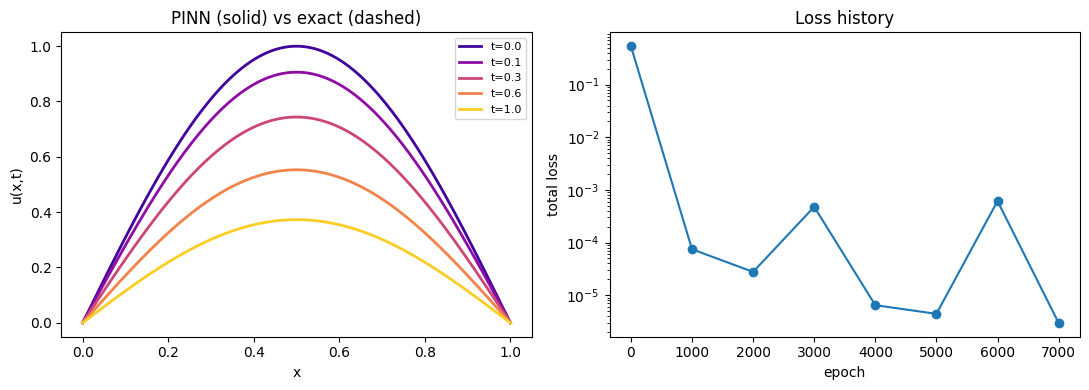

t=0.0  max|error| = 4.248e-04
t=0.1  max|error| = 3.704e-04
t=0.3  max|error| = 2.875e-04
t=0.6  max|error| = 2.505e-04
t=1.0  max|error| = 3.387e-04


In [5]:
xv = torch.linspace(0, 1, 200).reshape(-1,1).to(dv)
ts = [0.0, 0.1, 0.3, 0.6, 1.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(ts)))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

errs = []
for c, tv in zip(colors, ts):
    tv_t = torch.full_like(xv, tv)
    with torch.no_grad():
        yp = g(xv, tv_t).cpu().numpy().flatten()
    xe = xv.cpu().numpy().flatten()
    ye = np.exp(-np.pi**2 * al * tv) * np.sin(np.pi * xe)
    a1.plot(xe, yp, color=c, lw=2, label=f't={tv}')
    a1.plot(xe, ye, color=c, lw=1, ls='--')
    errs.append(np.max(np.abs(yp - ye)))

a1.set_xlabel('x'); a1.set_ylabel('u(x,t)')
a1.set_title('PINN (solid) vs exact (dashed)')
a1.legend(fontsize=8)

a2.semilogy(range(0, 8000, 1000), log, 'o-')
a2.set_xlabel('epoch'); a2.set_ylabel('total loss')
a2.set_title('Loss history')

plt.tight_layout(); plt.show()

for tv, e in zip(ts, errs):
    print(f"t={tv:.1f}  max|error| = {e:.3e}")